### Formulation of the problem:

#### Variables, Sets, Data:
- $x_{i,j} \in \{0,1\}$: decision variable, 1 if brick $i$ is assigned to SR $j$
- $x^0_{i,j} \in \{0,1\}$: initial assignment of brick $i$ to SR $j$ (given data, from the initial state)
- $d_{i,j}$: distance between brick $i$ and SR $j$ (data)
- $v_i$: workload for brick $i$ (value between 0 and 1) (data)
- $S$: set of SRs
- $B$: set of bricks $(1, 2, 3, \ldots)$

#### Constraints (30 in total):

Workload bounds for each SR:
$$
\sum_{i \in B} x_{i,1} \cdot v_i \leq 1.2, \quad
\sum_{i \in B} x_{i,2} \cdot v_i \leq 1.2, \quad
\sum_{i \in B} x_{i,3} \cdot v_i \leq 1.2, \quad
\sum_{i \in B} x_{i,4} \cdot v_i \leq 1.2
$$

$$
\sum_{i \in B} x_{i,1} \cdot v_i \geq 0.8, \quad
\sum_{i \in B} x_{i,2} \cdot v_i \geq 0.8, \quad
\sum_{i \in B} x_{i,3} \cdot v_i \geq 0.8, \quad
\sum_{i \in B} x_{i,4} \cdot v_i \geq 0.8
$$

Assignment constraints (one SR per brick), for each brick $i \in B$ (22 constraints):
$$
\sum_{j \in S} x_{i,j} = 1 
$$
(e.g. for $i = 1$: $\sum_{j \in S} x_{1,j} = 1$)

---

#### Objective Functions

**Distance objective (what the first model minimizes):**
$$
\min D(x) = \sum_{i \in B} \sum_{j \in S} d_{i,j} \, x_{i,j}
$$

**Weighted disruption objective (what the second model minimizes):**

We measure how much the new assignment $x_{i,j}$ deviates from the initial assignment $x^0_{i,j}$, weighted by the workload $v_i$, using exactly the quadratic form implemented in the code:

$$
\min R(x) = 
\sum_{i \in B} v_i \sum_{j \in S} 
\frac{1}{2}\left(
x^0_{i,j} - 2\,x^0_{i,j}\,x_{i,j} + x_{i,j}
\right)
$$

In [27]:
# pip install gurobipy

In [28]:
# Core imports
from gurobipy import Model, GRB
import numpy as np
import matplotlib.pyplot as plt


## Data

In [29]:
num_bricks = 22

###### --- Data ---
distances = [[16.16, 24.08, 24.32, 21.12], 
     [19, 26.47, 27.24, 17.33], 
     [25.29, 32.49, 33.42, 12.25], 
     [0, 7.93, 8.31, 36.12], 
     [3.07, 6.44, 7.56, 37.37], 
     [1.22, 7.51, 8.19, 36.29], 
     [2.80, 10.31, 10.95, 33.5], 
     [2.87, 5.07, 5.67, 38.8], 
     [3.8, 8.01, 7.41, 38.16], 
     [12.35, 4.52, 4.35, 48.27], 
     [11.11, 3.48, 2.97, 47.14], 
     [21.99, 22.02, 24.07, 39.86], 
     [8.82, 3.3, 5.36, 43.31], 
     [7.93, 0, 2.07, 43.75], 
     [9.34, 2.25, 1.11, 45.43], 
     [8.31, 2.07, 0, 44.43], 
     [7.31, 2.44, 1.11, 43.43], 
     [7.55, 0.75, 1.53, 43.52], 
     [11.13, 18.41, 19.26, 25.4], 
     [17.49, 23.44, 24.76, 23.21], 
     [11.03, 18.93, 19.28, 25.43], 
     [36.12, 43.75, 44.43, 0]] 

workloads = [0.1609, 0.1164, 0.1026, 0.1516, 0.0939, 
     0.1320, 0.0687, 0.0930, 0.2116, 0.2529, 
     0.0868, 0.0828, 0.0975, 0.8177, 0.4115, 
     0.3795, 0.0710, 0.0427, 0.1043, 0.0997, 
     0.1698, 0.2531]

## Initial state : 
SR1_center = [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
SR2_center = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
SR3_center = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
SR4_center = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]

SR1_initial_state = [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
SR2_initial_state = [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
SR3_initial_state = [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0]
SR4_initial_state = [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1]
SRs = [SR1_initial_state, SR2_initial_state, SR3_initial_state, SR4_initial_state]

## Initial state

In [30]:
# Inspect the initial assignment: bricks, workload, and distance per SR
initial_SRs = [SR1_initial_state, SR2_initial_state, SR3_initial_state, SR4_initial_state]

total_distance = 0.0
for sr_idx, SR in enumerate(initial_SRs):
    bricks_assigned = [j + 1 for j, val in enumerate(SR) if val == 1]
    workload_sr = sum(workloads[j] for j, val in enumerate(SR) if val == 1)
    distance_sr = sum(distances[j][sr_idx] for j, val in enumerate(SR) if val == 1)
    total_distance += distance_sr

    print(f"SR{sr_idx + 1}:")
    print(f"  - Bricks assigned : {bricks_assigned}")
    print(f"  - Workload        : {workload_sr:.3f}")
    print(f"  - Distance (km)   : {distance_sr:.2f}\n")

print(f"Total distance over all SRs = {total_distance:.2f} km")


SR1:
  - Bricks assigned : [4, 5, 6, 7, 8, 15]
  - Workload        : 0.951
  - Distance (km)   : 19.30

SR2:
  - Bricks assigned : [10, 11, 12, 13, 14]
  - Workload        : 1.338
  - Distance (km)   : 33.32

SR3:
  - Bricks assigned : [9, 16, 17, 18]
  - Workload        : 0.705
  - Distance (km)   : 10.05

SR4:
  - Bricks assigned : [1, 2, 3, 19, 20, 21, 22]
  - Workload        : 1.007
  - Distance (km)   : 124.74

Total distance over all SRs = 187.41 km


## First objective function : minimization Distance

In [31]:
# -------- Distance minimization model (22 bricks / 4 SRs) --------
# Objective: minimize total distance while keeping workloads in [0.8, 1.2]

model = Model("Bricks_and_Sales_Reps_Distance_22x4")

# --- Decision variables: x_{i,j} = 1 if brick i is assigned to SR j ---
SR_1 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_1")
SR_2 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_2")
SR_3 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_3")
SR_4 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_4")

# --- Workload balance constraints for each SR ---
for sr_idx, SR in enumerate([SR_1, SR_2, SR_3, SR_4], start=1):
    model.addConstr(
        sum(SR[i] * workloads[i] for i in range(num_bricks)) <= 1.2,
        name=f"max_workload_SR{sr_idx}"
    )
    model.addConstr(
        sum(SR[i] * workloads[i] for i in range(num_bricks)) >= 0.8,
        name=f"min_workload_SR{sr_idx}"
    )

# --- Each brick must be assigned to exactly one SR ---
for i in range(num_bricks):
    model.addConstr(
        SR_1[i] + SR_2[i] + SR_3[i] + SR_4[i] == 1,
        name=f"brick_{i + 1}_assignment"
    )

# --- Objective: total distance travelled over all SRs ---
distance_expr = sum(
    distances[i][0] * SR_1[i] +
    distances[i][1] * SR_2[i] +
    distances[i][2] * SR_3[i] +
    distances[i][3] * SR_4[i]
    for i in range(num_bricks)
)
model.setObjective(distance_expr, GRB.MINIMIZE)

# --- Solve the optimization problem ---
model.Params.OutputFlag = 0
model.optimize()


In [32]:
if model.status == GRB.OPTIMAL:
    print( "Find Optimal solution !")
    print( f"Minimal Distance Cost = {model.objVal:.2f}\n")

    # --- Afficher la répartition des briques ---
    for j, (SR, name) in enumerate(
        [(SR_1, "SR_1"), (SR_2, "SR_2"), (SR_3, "SR_3"), (SR_4, "SR_4")],
        start=1
    ):
        print(f"{name} :")
        total_load = sum(SR[i].x * workloads[i] for i in range(num_bricks))
        assigned = [i + 1 for i in range(num_bricks) if SR[i].x > 0.5]

        print(f"  - Assigned bricks : {assigned}")
        print(f"  - Total load     : {total_load:.3f}\n")
    
    # compute simple weighted disruption: sum of workloads of bricks that changed SR compared to the initial state
    disruptions = 0.0
    for i in range(num_bricks):
        if (SR_1[i].x > 0.5 and SR1_initial_state[i] == 0) or \
           (SR_2[i].x > 0.5 and SR2_initial_state[i] == 0) or \
           (SR_3[i].x > 0.5 and SR3_initial_state[i] == 0) or \
           (SR_4[i].x > 0.5 and SR4_initial_state[i] == 0):
            disruptions += 1  * workloads[i]

    print(f"Total weighted disruption: {disruptions}")

else:
    print(f" No optimal solution (status = {model.status})")

Find Optimal solution !
Minimal Distance Cost = 154.60

SR_1 :
  - Assigned bricks : [4, 5, 6, 7, 8, 9, 12, 19, 20]
  - Total load     : 1.038

SR_2 :
  - Assigned bricks : [11, 13, 14, 18]
  - Total load     : 1.045

SR_3 :
  - Assigned bricks : [10, 15, 16, 17]
  - Total load     : 1.115

SR_4 :
  - Assigned bricks : [1, 2, 3, 21, 22]
  - Total load     : 0.803

Total weighted disruption: 1.2055


## Second objective function : minimize the Disruption

In [33]:
model = Model("Bricks_and_Sales_Reps")

###### --- Variables ---
SR_1 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_1")
SR_2 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_2")
SR_3 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_3")
SR_4 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_4")


##### --- Constraints ---
# SR1  workloads
model.addConstr(sum(SR_1[i] * workloads[i] for i in range(num_bricks)) <= 1.2, name="max_workload_SR1")
model.addConstr(sum(SR_1[i] * workloads[i] for i in range(num_bricks)) >= 0.8, name="min_workload_SR1")

# SR2
model.addConstr(sum(SR_2[i] * workloads[i] for i in range(num_bricks)) <= 1.2, name="max_workload_SR2")
model.addConstr(sum(SR_2[i] * workloads[i] for i in range(num_bricks)) >= 0.8, name="min_workload_SR2")

# SR3
model.addConstr(sum(SR_3[i] * workloads[i] for i in range(num_bricks)) <= 1.2, name="max_workload_SR3")
model.addConstr(sum(SR_3[i] * workloads[i] for i in range(num_bricks)) >= 0.8, name="min_workload_SR3")

# SR4
model.addConstr(sum(SR_4[i] * workloads[i] for i in range(num_bricks)) <= 1.2, name="max_workload_SR4")
model.addConstr(sum(SR_4[i] * workloads[i] for i in range(num_bricks)) >= 0.8, name="min_workload_SR4")

# each brick must be assigned to exactly one SR
for i in range(num_bricks):
    model.addConstr( SR_1[i] + SR_2[i] + SR_3[i] + SR_4[i]   == 1, name=f"brick_{i+1}_assignment")

# --- Objective function 2 : Minimize the disruption ---
model.setObjective(
    sum(
        0.5 * (
            SR1_initial_state[i] - 2 * SR1_initial_state[i] * SR_1[i] + SR_1[i] +
            SR2_initial_state[i] - 2 * SR2_initial_state[i] * SR_2[i] + SR_2[i] +
            SR3_initial_state[i] - 2 * SR3_initial_state[i] * SR_3[i] + SR_3[i] +
            SR4_initial_state[i] - 2 * SR4_initial_state[i] * SR_4[i] + SR_4[i]
        ) * workloads[i]
        for i in range(num_bricks)
    ),
    GRB.MINIMIZE
)




# --- Resolve the optimization problem ---
model.Params.OutputFlag = 0
model.optimize()

In [34]:
if model.status == GRB.OPTIMAL:
    print( "Find Optimal solution !")
    print( f"Minimal Disruption Cost = {model.objVal:.2f}\n")

    # --- Afficher la répartition des briques ---
    for j, (SR, name) in enumerate(
        [(SR_1, "SR_1"), (SR_2, "SR_2"), (SR_3, "SR_3"), (SR_4, "SR_4")],
        start=1
    ):
        print(f"{name} :")
        total_load = sum(SR[i].x * workloads[i] for i in range(num_bricks))
        assigned = [i + 1 for i in range(num_bricks) if SR[i].x > 0.5]

        print(f"  - Assigned bricks : {assigned}")
        print(f"  - Total load     : {total_load:.3f}\n")

else:
    print(f" No optimal solution (status = {model.status})")

Find Optimal solution !
Minimal Disruption Cost = 0.17

SR_1 :
  - Assigned bricks : [4, 5, 6, 7, 8, 15]
  - Total load     : 0.951

SR_2 :
  - Assigned bricks : [10, 13, 14]
  - Total load     : 1.168

SR_3 :
  - Assigned bricks : [9, 11, 12, 16, 17, 18]
  - Total load     : 0.874

SR_4 :
  - Assigned bricks : [1, 2, 3, 19, 20, 21, 22]
  - Total load     : 1.007



### Epsilon method for three workload ranges: [0.8, 1.2], [0.9, 1.1], [0.85, 1.15]

ε = 0.17 → distance = 188.950, disruption = 0.1696
ε = 0.18 → distance = 188.950, disruption = 0.1696
ε = 0.19 → distance = 188.950, disruption = 0.1696
ε = 0.2 → distance = 188.950, disruption = 0.1696
ε = 0.21 → distance = 188.950, disruption = 0.1696
ε = 0.22 → distance = 188.950, disruption = 0.1696
ε = 0.23 → distance = 188.180, disruption = 0.2270
ε = 0.24 → distance = 188.180, disruption = 0.2270
ε = 0.25 → distance = 188.180, disruption = 0.2270
ε = 0.26 → distance = 187.240, disruption = 0.2529
ε = 0.27 → distance = 183.230, disruption = 0.2693
ε = 0.28 → distance = 174.680, disruption = 0.2739
ε = 0.29 → distance = 174.680, disruption = 0.2739
ε = 0.3 → distance = 174.680, disruption = 0.2739
ε = 0.31 → distance = 174.680, disruption = 0.2739
ε = 0.32 → distance = 174.680, disruption = 0.2739
ε = 0.33 → distance = 174.680, disruption = 0.2739
ε = 0.34 → distance = 173.910, disruption = 0.3313
ε = 0.35000000000000003 → distance = 173.910, disruption = 0.3313
ε = 0.36 → distanc

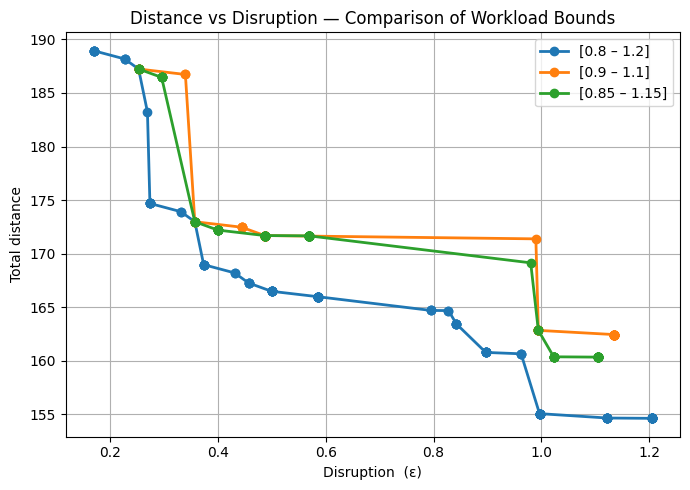

In [35]:
# Epsilon-constraint scheme for the 22x4 instance
# We generate non-dominated (disruption, distance) solutions
import matplotlib.pyplot as plt
from gurobipy import Model, GRB

# --- Settings ---
num_bricks = 22
num_SR = 4

# === Fonction utilitaire pour une config donnée ===
def solve_pareto(model_name, workload_min, workload_max):
    model = Model(model_name)
    model.Params.OutputFlag = 0

    # Variables
    SR_1 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_1")
    SR_2 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_2")
    SR_3 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_3")
    SR_4 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_4")

    # Contraintes de charge
    for j, SR in enumerate([SR_1, SR_2, SR_3, SR_4], start=1):
        model.addConstr(sum(SR[i] * workloads[i] for i in range(num_bricks)) <= workload_max,
                        name=f"max_workload_SR{j}")
        model.addConstr(sum(SR[i] * workloads[i] for i in range(num_bricks)) >= workload_min,
                        name=f"min_workload_SR{j}")

    # Une seule affectation par brique
    for i in range(num_bricks):
        model.addConstr(SR_1[i] + SR_2[i] + SR_3[i] + SR_4[i] == 1, name=f"brick_{i+1}_assignment")

    # Objectif 1 : distance
    distance_expr = sum(
        distances[i][0] * SR_1[i] +
        distances[i][1] * SR_2[i] +
        distances[i][2] * SR_3[i] +
        distances[i][3] * SR_4[i]
        for i in range(num_bricks)
    )

    # Objectif 2 : disruption
    disruption_expr = sum(
        ((SR1_initial_state[i] - 2 * SR1_initial_state[i] * SR_1[i] + SR_1[i] +
          SR2_initial_state[i] - 2 * SR2_initial_state[i] * SR_2[i] + SR_2[i] +
          SR3_initial_state[i] - 2 * SR3_initial_state[i] * SR_3[i] + SR_3[i] +
          SR4_initial_state[i] - 2 * SR4_initial_state[i] * SR_4[i] + SR_4[i]) / 2) * workloads[i]
        for i in range(num_bricks)
    )

    # Pareto frontier
    epsilons = np.arange(0.0, 1.4, 0.01)  # from 0.0 to 1.4 with step 0.01
    pareto_points = []

    for eps in epsilons:
        constr = model.addConstr(disruption_expr <= eps + 1e-6, name=f"eps_{eps}")
        model.setObjective(distance_expr, GRB.MINIMIZE)
        model.Params.OutputFlag = 0
        model.optimize()

        if model.status == GRB.OPTIMAL:
            d = distance_expr.getValue()
            r = disruption_expr.getValue()
            pareto_points.append((r, d))   # store REAL disruption
            print(f"ε = {eps:>3} → distance = {d:.3f}, disruption = {r:.4f}")

        model.remove(constr)
        model.update()


    return pareto_points


# === Résolution pour les 3 scénarios ===
pareto_12 = solve_pareto("model_08_12", 0.8, 1.2)
pareto_11 = solve_pareto("model_09_11", 0.9, 1.1)
pareto_115 = solve_pareto("model_085_115", 0.85, 1.15)

# === Tracé comparatif ===
plt.figure(figsize=(7, 5))
if pareto_12:
    eps_vals, costs = zip(*pareto_12)
    plt.plot(eps_vals, costs, 'o-', label='[0.8 – 1.2]', linewidth=2)
if pareto_11:
    eps_vals, costs = zip(*pareto_11)
    plt.plot(eps_vals, costs, 'o-', label='[0.9 – 1.1]', linewidth=2)
if pareto_115:
    eps_vals, costs = zip(*pareto_115)
    plt.plot(eps_vals, costs, 'o-', label='[0.85 – 1.15]', linewidth=2)

plt.xlabel("Disruption  (ε)")
plt.ylabel("Total distance")
plt.title("Distance vs Disruption — Comparison of Workload Bounds")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Instance with 10 SRs and 100 zones

Disruption minimale : 0.2929, distance = 191.701
Distance minimale : 70.790, disruption = 8.4544
ε = 0.3 → distance = 186.376, disruption = 0.2993
ε = 0.6 → distance = 159.616, disruption = 0.5974
ε = 0.8999999999999999 → distance = 147.517, disruption = 0.8989
ε = 1.2 → distance = 138.710, disruption = 1.1987
ε = 1.5 → distance = 131.174, disruption = 1.4972
ε = 1.7999999999999998 → distance = 123.945, disruption = 1.7979
ε = 2.1 → distance = 118.112, disruption = 2.0999
ε = 2.4 → distance = 112.405, disruption = 2.3924
ε = 2.6999999999999997 → distance = 107.091, disruption = 2.6992
ε = 3.0 → distance = 102.334, disruption = 2.9975
ε = 3.3 → distance = 98.232, disruption = 3.2956
ε = 3.5999999999999996 → distance = 95.281, disruption = 3.5826
ε = 3.9 → distance = 92.843, disruption = 3.8903
ε = 4.2 → distance = 90.118, disruption = 4.1988
ε = 4.5 → distance = 87.500, disruption = 4.4966
ε = 4.8 → distance = 85.416, disruption = 4.7764
ε = 5.1 → distance = 83.191, disruption = 5.0750


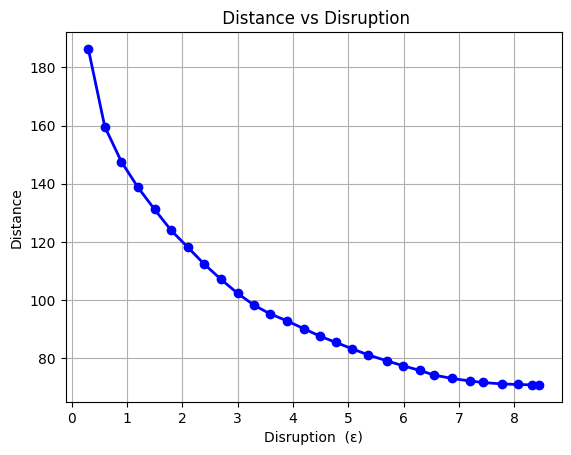

In [36]:
model = Model("Bricks_and_Sales_Reps_100")
 
Bricks=100
Sales = 10
### Creat data 
#Randome Workloads 100 
workloads = np.random.rand(Bricks)
# sum workloads = 10
workloads = workloads/sum(workloads)*Sales
 
#Randome distance 100 
np.random.seed(12)
x_Brics = np.random.rand(Bricks)**2 *4
np.random.seed(10)
Y_Brics  = np.random.rand(Bricks)**2 *4
#Implementation of Distance Matrix with center for each SR
Distance = np.array([ np.sqrt((x_Brics[:] - x_Brics[i])**2 + (Y_Brics[:] - Y_Brics[i])**2) for i in range(Sales) ])

#Creat an initial state that takes into account the center of each SR
SR_initial_state = np.zeros((Sales, Bricks), dtype=float)
 
for i in range(Bricks):
    j = i % Sales
    SR_initial_state[j,i] = 1
 
#Variables
SR_10 = model.addVars(Sales, Bricks, vtype=GRB.BINARY, name="SR_10")
 
## Constraints Workloads
for j in range(Sales):
    model.addConstr(
        sum(SR_10[j,i] * workloads[i] for i in range(Bricks)) <= 1.2,
        name=f"max_workload_10SR_{j}"
    )
    model.addConstr(
        sum(SR_10[j,i] * workloads[i] for i in range(Bricks)) >= 0.8,
        name=f"min_workload_10SR_{j}"
    )
## Constraints Bricks
for i in range(Bricks):
    model.addConstr( sum(SR_10[j,i] for j in range(Sales))    == 1, name=f"brick_{i+1}_assignment")
 
 
# --- Objective 1 : total distance ---
distance_expr = ( sum(
    Distance[j][i] * SR_10[j,i] 
    for i in range(Bricks)
    for j in range(Sales) 
)
)
 
 
# --- Objective 2 : disruption ---
disruption_expr = sum(
    (SR_initial_state[j,i] - 2 * SR_initial_state[j,i] * SR_10[j,i] + SR_10[j,i] )*workloads[i]/2
    for i in range(Bricks) for j in range(Sales)
)
 
model.Params.OutputFlag = 0  # silencieux
 
# 1) Solution qui minimise la disruption seule
model.setObjective(disruption_expr, GRB.MINIMIZE)
model.optimize()
disruption_min = disruption_expr.getValue()
distance_at_disruption_min = distance_expr.getValue()
 
print(f"Disruption minimale : {disruption_min:.4f}, distance = {distance_at_disruption_min:.3f}")
 
# 2) Solution qui minimise la distance seule
model.setObjective(distance_expr, GRB.MINIMIZE)
model.optimize()
disruption_at_distance_min = disruption_expr.getValue()
distance_min = distance_expr.getValue()
 
print(f"Distance minimale : {distance_min:.3f}, disruption = {disruption_at_distance_min:.4f}")
 
# 3) Construire un vecteur epsilon entre ces deux extrêmes
epsilons = np.arange(0.0, 9, 0.3)  # from 0.0 to 9.0 with step 0.3
pareto_points = []

for eps in epsilons:
    constr = model.addConstr(disruption_expr <= eps + 1e-6, name=f"eps_{eps}")
    model.setObjective(distance_expr, GRB.MINIMIZE)
    model.Params.OutputFlag = 0
    model.optimize()

    if model.status == GRB.OPTIMAL:
        d = distance_expr.getValue()
        r = disruption_expr.getValue()
        pareto_points.append((r, d))   # store REAL disruption
        print(f"ε = {eps:>3} → distance = {d:.3f}, disruption = {r:.4f}")

    model.remove(constr)
    model.update()
 
 
print("\nPareto points (disruption, distance):")
for p in pareto_points:
    print(p)
if pareto_points:
    eps_vals, costs = zip(*pareto_points)
    plt.plot(eps_vals, costs, 'o-', color='blue', linewidth=2)
    plt.xlabel("Disruption  (ε)")
    plt.ylabel("Distance")
    plt.title(" Distance vs Disruption")
    plt.grid(True)
    plt.show()

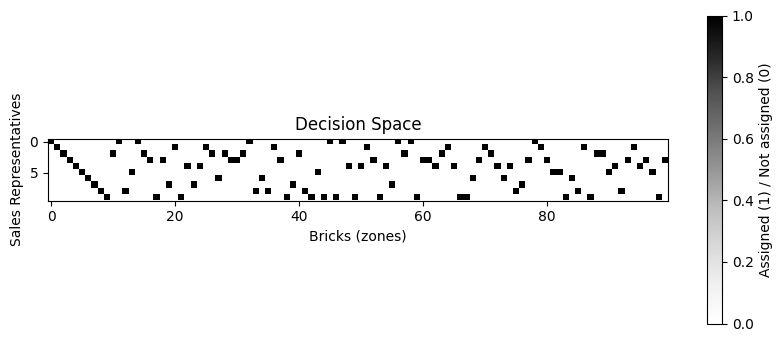

In [37]:
model.optimize()
 
assign = np.zeros((Sales, Bricks))
for j in range(Sales):
    for i in range(Bricks):
        assign[j, i] = SR_10[j, i].X  
 
plt.figure(figsize=(10, 4))
plt.imshow(assign, cmap="Greys", interpolation="nearest")
plt.xlabel("Bricks (zones)")
plt.ylabel("Sales Representatives")
plt.title("Decision Space")
plt.colorbar(label="Assigned (1) / Not assigned (0)")
plt.show()

In [38]:
model = Model("Bricks_and_Sales_Reps_100")
 
Bricks=100
Sales = 10
### Creat data 
#Randome Workloads 100 
workloads = np.random.rand(Bricks)
# sum workloads = 10
workloads = workloads/sum(workloads)*Sales
 
#Randome distance 100 
np.random.seed(12)
x_Brics = np.random.rand(Bricks)**2 *4
np.random.seed(10)
Y_Brics  = np.random.rand(Bricks)**2 *4
#Implementation of Distance Matrix with center for each SR
Distance = np.array([ np.sqrt((x_Brics[:] - x_Brics[i])**2 + (Y_Brics[:] - Y_Brics[i])**2) for i in range(Sales) ])
 
#Creat an initial state that takes into account the center of each SR
SR_initial_state = np.zeros((Sales, Bricks), dtype=float)
 
for i in range(Bricks):
    j = i % Sales
    SR_initial_state[j,i] = 1
 
#Variables
SR_10 = model.addVars(Sales, Bricks, vtype=GRB.BINARY, name="SR_10")
 
## Constraints Workloads
for j in range(Sales):
    model.addConstr(
        sum(SR_10[j,i] * workloads[i] for i in range(Bricks)) <= 1.2,
        name=f"max_workload_10SR_{j}"
    )
    model.addConstr(
        sum(SR_10[j,i] * workloads[i] for i in range(Bricks)) >= 0.8,
        name=f"min_workload_10SR_{j}"
    )
## Constraints Bricks
for i in range(Bricks):
    model.addConstr( sum(SR_10[j,i] for j in range(Sales))    == 1, name=f"brick_{i+1}_assignment")
 
 
# --- Objective 1 : total distance ---
distance_expr = ( sum(
    Distance[j][i] * SR_10[j,i] 
    for i in range(Bricks)
    for j in range(Sales) 
)
)
 
 
# --- Objective 2 : disruption ---
disruption_expr = sum(
    (SR_initial_state[j,i] - 2 * SR_initial_state[j,i] * SR_10[j,i] + SR_10[j,i] )*workloads[i]/2
    for i in range(Bricks) for j in range(Sales)
)
 
model.Params.OutputFlag = 0  # silencieux

# ==========================
# 1) Solution qui minimise la disruption seule
# ==========================
model.setObjective(disruption_expr, GRB.MINIMIZE)
model.optimize()

disruption_min = disruption_expr.getValue()
distance_at_disruption_min = distance_expr.getValue()

# ---> SAUVEGARDER l'affectation pour cette solution
assign_disruption = np.zeros(Bricks, dtype=int)  # taille 100

for i in range(Bricks):
    # On récupère les valeurs SR_10[j,i].X pour j = 0..9
    vals = [SR_10[j, i].X for j in range(Sales)]
    # argmax donne le SR qui a la valeur 1 (ou la plus grande)
    best_j = int(np.argmax(vals))   # entre 0 et 9
    assign_disruption[i] = best_j

print(f"Disruption minimale : {disruption_min:.4f}, distance = {distance_at_disruption_min:.3f}")


# ==========================
# 2) Solution qui minimise la distance seule
# ==========================
model.setObjective(distance_expr, GRB.MINIMIZE)
model.optimize()

disruption_at_distance_min = disruption_expr.getValue()
distance_min = distance_expr.getValue()

# ---> SAUVEGARDER l'affectation pour cette solution
assign_distance = np.zeros(Bricks, dtype=int)

for i in range(Bricks):
    vals = [SR_10[j, i].X for j in range(Sales)]
    best_j = int(np.argmax(vals))
    assign_distance[i] = best_j

print(f"Distance minimale : {distance_min:.3f}, disruption = {disruption_at_distance_min:.4f}")

Disruption minimale : 0.2929, distance = 191.701
Distance minimale : 70.790, disruption = 8.4544


C:\Users\simor\AppData\Local\Temp\ipykernel_35692\3445285300.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', Sales)


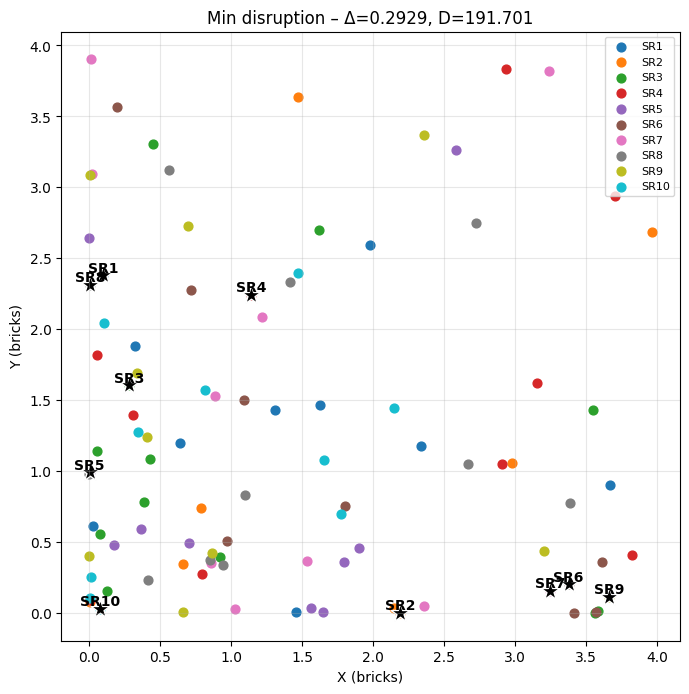

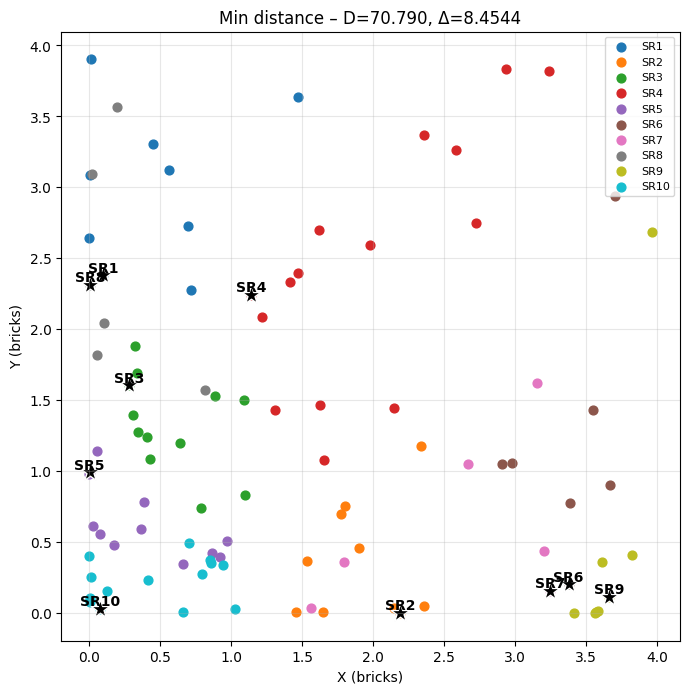

In [39]:
def plot_assignment_map(title, assignment, x_coords, y_coords, Sales):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(7, 7))
    ax = plt.gca()

    cmap = plt.cm.get_cmap('tab10', Sales)

    # Bricks colorés selon le SR
    for j in range(Sales):
        mask = (assignment == j)
        if not np.any(mask):
            continue
        plt.scatter(
            x_coords[mask],
            y_coords[mask],
            s=40,
            color=cmap(j),
            label=f"SR{j+1}"
        )

    # Centres des SRs (ici on suppose centre = brick j)
    for j in range(Sales):
        cx, cy = x_coords[j], y_coords[j]
        plt.scatter(cx, cy, marker="*", s=200, color="black", edgecolor="white")
        plt.text(cx, cy, f"SR{j+1}", fontsize=10, ha="center", va="bottom", fontweight="bold")

    ax.set_aspect("equal", "box")
    plt.title(title)
    plt.xlabel("X (bricks)")
    plt.ylabel("Y (bricks)")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()


plot_assignment_map(
    title=f"Min disruption – Δ={disruption_min:.4f}, D={distance_at_disruption_min:.3f}",
    assignment=assign_disruption,
    x_coords=x_Brics,
    y_coords=Y_Brics,
    Sales=Sales
)

plot_assignment_map(
    title=f"Min distance – D={distance_min:.3f}, Δ={disruption_at_distance_min:.4f}",
    assignment=assign_distance,
    x_coords=x_Brics,
    y_coords=Y_Brics,
    Sales=Sales
)